# Bounded ATMS Hallucination Meter for Text-to-Logic Reasoning

This notebook demonstrates the **Bounded ATMS Hallucination Meter**, a two-layer neuro-symbolic pipeline that separates document grounding (L1) from assumption tracking (L2) to score how much "hallucination" is needed to derive a conclusion.

**Pipeline overview:**
- **L1 Grounding**: An LLM extracts explicit atomic facts with grounding spans from documents
- **L2 Assumption Tracking**: An LLM proposes fuzzy unifications and bridge rules; each is seeded as an ATMS assumption
- **BoundedATMS**: Forward-chains environments up to `depth_cap=3` with `beam_width=20`
- **Assumption Load**: Minimum supporting environment size — 0 = grounded fact (hallucination-free), inf = not derivable

The demo loads precomputed results and re-runs the deterministic ATMS stage on a worked example.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab
_pip('aiohttp==3.9.5')
_pip('tenacity==8.3.0')
_pip('loguru==0.7.2')
_pip('json5==0.9.25')

# Core packages pre-installed on Colab — install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import asyncio
import gc
import json
import math
import os
import re
import sys
import time
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from loguru import logger

# Logging setup from original script
logger.remove()
GREEN, CYAN, END = "\033[92m", "\033[96m", "\033[0m"
logger.add(
    sys.stdout,
    level="INFO",
    format=f"{GREEN}{{time:HH:mm:ss}}{END}|{{level:<7}}|{CYAN}{{function}}{END}| {{message}}",
)

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-70ae4e-the-empty-environment-test-calibration-f/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {sum(len(d['examples']) for d in data['datasets'])} examples across {len(data['datasets'])} datasets")
print(f"Method: {data['metadata']['method_name']}")

Loaded 9 examples across 3 datasets
Method: Bounded-ATMS Hallucination Meter


## Configuration

All tunable parameters from the original experiment. The demo uses the original values since the ATMS is purely deterministic (no API calls needed).

In [5]:
# ─── Config ───────────────────────────────────────────────────────────────────
# Original values from the paper experiment
DEPTH_CAP = 3          # max assumption depth for ATMS environments
BEAM_WIDTH = 20        # max environments per node (beam pruning)
ASSUMPTION_THRESHOLD = 2  # load < threshold → answer yes, else abstain
LINC_K = 3             # majority vote samples for LINC baseline

# LLM config (only used if running full pipeline with API key)
OPENROUTER_KEY = os.environ.get("OPENROUTER_API_KEY", "")
CHEAP_MODEL = "meta-llama/llama-3.1-8b-instruct"
COST_CAP = 9.0

## Bounded ATMS Implementation

The `BoundedATMS` class is the core of the system. It maintains **environments** — sets of assumptions — for each derived node. The key invariant: if a node can be derived from a subset of assumptions `E`, then `E` is a minimal environment in that node's label.

- `depth_cap`: discards environments larger than this (tractability bound)
- `beam_width`: keeps only the smallest `beam_width` environments per node
- `assumption_load(node)`: returns `min(|E| for E in label)`, 0 if grounded, inf if not derivable

In [6]:
@dataclass
class Assumption:
    id: str
    text: str
    weight: float  # 0-1, LLM-proposed confidence


@dataclass
class Node:
    id: str
    label: set  # set of frozenset[str] — minimal environments

    def __post_init__(self):
        if not isinstance(self.label, set):
            self.label = set(self.label)


class BoundedATMS:
    def __init__(self, depth_cap: int = 3, beam_width: int = 20):
        self.depth_cap = depth_cap
        self.beam_width = beam_width
        self.assumptions: dict[str, Assumption] = {}
        self.nodes: dict[str, Node] = {}
        self.nogoods: list[frozenset] = []
        self._rules: list[tuple[list[str], str]] = []  # (antecedents, consequent)

    def _add_env_to_label(self, node_id: str, env: frozenset) -> bool:
        """Add env to node's label. Returns True if label changed."""
        node = self.nodes[node_id]
        # Check if env is already subsumed by an existing entry
        for existing in node.label:
            if existing <= env:  # existing is subset of env → env is redundant
                return False
        # Check depth cap
        if len(env) > self.depth_cap:
            return False
        # Check against nogoods
        for ng in self.nogoods:
            if ng <= env:
                return False
        # Remove any existing entries that are supersets of env (env subsumes them)
        to_remove = {e for e in node.label if env < e}
        node.label -= to_remove
        node.label.add(env)
        # Trim to beam_width: keep beam_width smallest (by size, then lex)
        if len(node.label) > self.beam_width:
            sorted_envs = sorted(node.label, key=lambda e: (len(e), sorted(e)))
            node.label = set(sorted_envs[: self.beam_width])
        return True

    def _get_or_create(self, node_id: str) -> Node:
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(id=node_id, label=set())
        return self.nodes[node_id]

    def add_fact(self, node_id: str, env: frozenset | None = None) -> None:
        """Add a fact supported by env (default: empty = grounded)."""
        if env is None:
            env = frozenset()
        self._get_or_create(node_id)
        self._add_env_to_label(node_id, env)

    def add_assumption(self, assumption: Assumption) -> str:
        """Create an assumption node with singleton environment {assumption.id}."""
        self.assumptions[assumption.id] = assumption
        self._get_or_create(assumption.id)
        self._add_env_to_label(assumption.id, frozenset([assumption.id]))
        return assumption.id

    def add_rule(
        self,
        antecedents: list[str],
        consequent: str,
        via_assumption: str | None = None,
    ) -> None:
        """Register a rule and immediately forward-chain it."""
        rule_env_extra = frozenset([via_assumption]) if via_assumption else frozenset()
        self._get_or_create(consequent)
        for ant in antecedents:
            self._get_or_create(ant)
        self._rules.append((antecedents, consequent, rule_env_extra))
        self._fire_rule(antecedents, consequent, rule_env_extra)

    def _fire_rule(
        self,
        antecedents: list[str],
        consequent: str,
        rule_env_extra: frozenset,
    ) -> bool:
        """Derive new environments for consequent from antecedents."""
        changed = False
        # Collect all combinations of one env from each antecedent
        ant_labels = []
        for ant in antecedents:
            node = self.nodes.get(ant)
            if node is None or not node.label:
                return False
            ant_labels.append(list(node.label))

        # Enumerate Cartesian product (capped)
        def product_envs(labels: list[list[frozenset]], limit: int = 200):
            if not labels:
                yield frozenset()
                return
            first, rest = labels[0], labels[1:]
            count = 0
            for env in first:
                for rest_env in product_envs(rest, limit):
                    yield env | rest_env
                    count += 1
                    if count >= limit:
                        return

        for combined in product_envs(ant_labels):
            final_env = combined | rule_env_extra
            if self._add_env_to_label(consequent, final_env):
                changed = True
        return changed

    def add_nogood(self, assumption_ids: frozenset) -> None:
        """Register a nogood and propagate to prune labels."""
        self.nogoods.append(assumption_ids)
        # Prune all nodes
        for node in self.nodes.values():
            to_remove = {e for e in node.label if assumption_ids <= e}
            node.label -= to_remove

    def merge_nodes(self, node_id1: str, node_id2: str, via_assumption: str) -> None:
        """Unification: node1 and node2 share environments via an assumption."""
        n1 = self.nodes.get(node_id1)
        n2 = self.nodes.get(node_id2)
        assumption_env = frozenset([via_assumption])
        if n1:
            for env in list(n1.label):
                self._add_env_to_label(node_id2, env | assumption_env)
        if n2:
            for env in list(n2.label):
                self._add_env_to_label(node_id1, env | assumption_env)

    def propagate(self) -> None:
        """Re-fire all rules until fixpoint (max 10 iterations)."""
        for _ in range(10):
            changed = False
            for antecedents, consequent, rule_env_extra in self._rules:
                if self._fire_rule(antecedents, consequent, rule_env_extra):
                    changed = True
            if not changed:
                break

    def assumption_load(self, node_id: str) -> float:
        """Min size of minimal supporting env. 0=grounded, inf=not derivable."""
        node = self.nodes.get(node_id)
        if node is None or not node.label:
            return float("inf")
        if frozenset() in node.label:
            return 0.0
        return float(min(len(e) for e in node.label))

    def is_empty_env_derivable(self, node_id: str) -> bool:
        node = self.nodes.get(node_id)
        if node is None:
            return False
        return frozenset() in node.label


def score_conclusion(atms: BoundedATMS, query_node: str) -> dict:
    load = atms.assumption_load(query_node)
    is_empty = atms.is_empty_env_derivable(query_node)
    envs = atms.nodes.get(query_node)
    return {
        "assumption_load": load,
        "empty_env_derivable": is_empty,
        "minimal_environments": [list(e) for e in (envs.label if envs else set())],
        "derivable": load < float("inf"),
    }


def method_answer(score: dict) -> str:
    """Answer yes/no if derivable with low assumption load; abstain otherwise."""
    if not score["derivable"]:
        return "abstain"
    # Derivable: if empty-env or low load → yes (conclusion follows), else abstain
    if score["assumption_load"] <= ASSUMPTION_THRESHOLD:
        return "yes"
    # High assumption load: still make a probabilistic guess but mark as uncertain
    return "abstain"


print("BoundedATMS classes defined.")

BoundedATMS classes defined.


## Ontology Rules & Canonical Predicate Matching

Synonym regex patterns bridge LLM output variation to deterministic ATMS symbol matching. For example, `parent`, `father`, `mother`, `dad`, `mom` all map to the same `parent(X,Y)` canonical form. Domain-specific forward rules (kinship transitivity, bAbI location propagation) are then applied to the L1 atoms.

In [7]:
# Canonical parent predicates (LLM may use any of these)
_PARENT_PREDS = re.compile(
    r'^(parent|father|mother|dad|mom|is_parent|is_father|is_mother|parent_of)\((.+?),(.+?)\)$',
    re.IGNORECASE,
)
_SIBLING_PREDS = re.compile(
    r'^(sibling|brother|sister|is_sibling|sibling_of)\((.+?),(.+?)\)$',
    re.IGNORECASE,
)
# Location predicates
_TRAVELED_PREDS = re.compile(
    r'^(traveled_to|went_to|moved_to|went|traveled|at|is_at|location)\((.+?),(.+?)\)$',
    re.IGNORECASE,
)
_PICKUP_PREDS = re.compile(r'^(picked_up|picked|grabbed|has)\((.+?),(.+?)\)$', re.IGNORECASE)
_DROP_PREDS = re.compile(r'^(dropped|put_down|left)\((.+?),(.+?)\)$', re.IGNORECASE)


def _apply_kinship_rules(atms: BoundedATMS) -> None:
    """Apply kinship transitivity rules to existing L1 nodes."""
    node_ids = list(atms.nodes.keys())
    parents: list[tuple[str, str, str]] = []  # (X, Y, node_id)
    siblings: list[tuple[str, str, str]] = []
    for nid in node_ids:
        m = _PARENT_PREDS.match(nid)
        if m:
            parents.append((m.group(2).strip(), m.group(3).strip(), nid))
            # Also add canonical parent(X,Y) fact if not using that name
            if not nid.startswith("parent("):
                can_nid = f"parent({m.group(2).strip()},{m.group(3).strip()})"
                atms.add_fact(can_nid, env=frozenset())
                parents.append((m.group(2).strip(), m.group(3).strip(), can_nid))
        m = _SIBLING_PREDS.match(nid)
        if m:
            siblings.append((m.group(2).strip(), m.group(3).strip(), nid))

    seen_parent_pairs = set()
    for x, y1, nid1 in parents:
        for y2, z, nid2 in parents:
            if y1 == y2 and (x, z) not in seen_parent_pairs:
                seen_parent_pairs.add((x, z))
                gp_node = f"grandparent({x},{z})"
                atms._get_or_create(gp_node)
                atms.add_rule([nid1, nid2], gp_node)
                # Also fire great-grandparent
                for y3, w, nid3 in parents:
                    if y3 == z:
                        ggp_node = f"great_grandparent({x},{w})"
                        atms._get_or_create(ggp_node)
                        atms.add_rule([nid1, nid2, nid3], ggp_node)

    for x, y, nid in siblings:
        # Symmetry
        sym_node = f"sibling({y},{x})"
        atms._get_or_create(sym_node)
        atms.add_rule([nid], sym_node)

    # parent + sibling → uncle/aunt (generic relation node)
    for px, py, pnid in parents:
        for sx, sy, snid in siblings:
            if py == sx:
                rel_node = f"aunt_or_uncle({px},{sy})"
                atms._get_or_create(rel_node)
                atms.add_rule([pnid, snid], rel_node)


def _apply_location_rules(atms: BoundedATMS) -> None:
    """Apply location rules to existing L1 nodes (bAbI style)."""
    node_ids = list(atms.nodes.keys())
    ats: list[tuple[str, str, str]] = []

    for nid in node_ids:
        m = _TRAVELED_PREDS.match(nid)
        if m:
            p, loc = m.group(2).strip(), m.group(3).strip()
            # traveled_to(X,L) → at(X,L)
            at_node = f"at({p},{loc})"
            atms.add_fact(at_node, env=frozenset())
            ats.append((p, loc, at_node))
        m = _PICKUP_PREDS.match(nid)
        if m:
            person, obj = m.group(2).strip(), m.group(3).strip()
            # picked_up(X,O) → has(X,O)
            has_node = f"has({person},{obj})"
            atms.add_fact(has_node, env=frozenset())
        m = _DROP_PREDS.match(nid)

    # has(X,O) + at(X,L) → at(O,L)
    has_facts = [(p, o, nid) for nid in node_ids if (m := re.match(r'has\((.+?),(.+?)\)', nid)) for p, o in [(m.group(1), m.group(2))]]
    for p1, loc, at_nid in ats:
        for p2, obj, has_nid in has_facts:
            if p1 == p2:
                obj_at_node = f"at({obj},{loc})"
                atms._get_or_create(obj_at_node)
                atms.add_rule([at_nid, has_nid], obj_at_node)

    # same_location: at(X,L) + at(Y,L) → same_location(X,Y)
    for p1, loc1, nid1 in ats:
        for p2, loc2, nid2 in ats:
            if loc1 == loc2 and p1 != p2:
                sl_node = f"same_location({p1},{p2})"
                atms._get_or_create(sl_node)
                atms.add_rule([nid1, nid2], sl_node)


def build_atms(
    l1_atoms: list[dict],
    l2: dict,
    query_node: str,
    domain: str = "clutrr",
) -> BoundedATMS:
    """Build and propagate ATMS from L1 atoms + L2 assumptions."""
    atms = BoundedATMS(depth_cap=DEPTH_CAP, beam_width=BEAM_WIDTH)

    # Seed L1 atoms as grounded (empty environment)
    for atom in l1_atoms:
        if atom.get("node_id"):
            atms.add_fact(atom["node_id"], env=frozenset())

    # Add query target node
    atms._get_or_create(query_node)

    # L2 unifications
    assumption_counter = [0]
    def new_assumption_id() -> str:
        assumption_counter[0] += 1
        return f"a{assumption_counter[0]}"

    for u in l2.get("unifications", []):
        a_id = new_assumption_id()
        a = Assumption(id=a_id, text=f"{u['atom1']}={u['atom2']}", weight=u["weight"])
        atms.add_assumption(a)
        atms._get_or_create(u["atom1"])
        atms._get_or_create(u["atom2"])
        atms.merge_nodes(u["atom1"], u["atom2"], via_assumption=a_id)

    # L2 bridge rules
    for b in l2.get("bridge_rules", []):
        a_id = new_assumption_id()
        a = Assumption(id=a_id, text=b["consequent"], weight=b["weight"])
        atms.add_assumption(a)
        for ant in b["antecedent"]:
            atms._get_or_create(ant)
        atms.add_rule(b["antecedent"], b["consequent"], via_assumption=a_id)

    # Apply domain ontology rules to L1 atoms
    if domain in ("clutrr", "custom"):
        _apply_kinship_rules(atms)
    else:
        _apply_location_rules(atms)

    atms.propagate()
    return atms


print("Ontology rules and build_atms() defined.")

Ontology rules and build_atms() defined.


## Worked Example: ATMS on a Kinship Chain

We manually run the ATMS on the first CLUTRR example from the dataset: *"Alice is Bob's mother. Bob is Carol's father. → Is Alice Carol's grandmother?"*

The L1 atoms (extracted grounded facts) and L2 assumptions (bridge rules proposed by LLM) are provided manually here — in the full pipeline, these come from LLM calls. The ATMS derivation is deterministic.

In [8]:
# Manually constructed L1 atoms (what the LLM would extract)
l1_atoms_example = [
    {"node_id": "mother(alice,bob)", "predicate": "mother", "arg1": "alice", "arg2": "bob",
     "span": "Alice is Bob's mother", "grounding_verified": True},
    {"node_id": "father(bob,carol)", "predicate": "father", "arg1": "bob", "arg2": "carol",
     "span": "Bob is Carol's father", "grounding_verified": True},
]

# No L2 assumptions needed — derivable directly from L1 via kinship rules
l2_example = {"unifications": [], "bridge_rules": []}

# Build the ATMS
query_node = "grandparent(alice,carol)"
atms = build_atms(l1_atoms_example, l2_example, query_node, domain="clutrr")

# Score the query conclusion
score = score_conclusion(atms, query_node)
answer = method_answer(score)

print(f"Query: Is Alice Carol's grandmother?")
print(f"  assumption_load     : {score['assumption_load']}  (0 = grounded, inf = not derivable)")
print(f"  empty_env_derivable : {score['empty_env_derivable']}  (directly from L1 facts)")
print(f"  minimal_environments: {score['minimal_environments']}  (empty set = no assumptions needed)")
print(f"  method answer       : {answer}")
print()
print("Nodes in ATMS:")
for nid, node in sorted(atms.nodes.items()):
    if node.label:
        envs_str = [str(set(e)) if e else "{}" for e in node.label]
        print(f"  {nid:40s} → {envs_str}")

Query: Is Alice Carol's grandmother?
  assumption_load     : 0.0  (0 = grounded, inf = not derivable)
  empty_env_derivable : True  (directly from L1 facts)
  minimal_environments: [[]]  (empty set = no assumptions needed)
  method answer       : yes

Nodes in ATMS:
  father(bob,carol)                        → ['{}']
  grandparent(alice,carol)                 → ['{}']
  mother(alice,bob)                        → ['{}']
  parent(alice,bob)                        → ['{}']
  parent(bob,carol)                        → ['{}']


## High-Load Example: When Assumptions Are Required

For *"John married Mary. Mary is Lisa's mother. John is Peter's father. → Are Lisa and Peter siblings?"*, the sibling relationship is NOT directly derivable from kinship rules — it requires an assumption (bridge rule) that children of the same parents are siblings.

In [9]:
l1_atoms_high = [
    {"node_id": "married(john,mary)", "predicate": "married", "arg1": "john", "arg2": "mary",
     "span": "John married Mary", "grounding_verified": True},
    {"node_id": "mother(mary,lisa)", "predicate": "mother", "arg1": "mary", "arg2": "lisa",
     "span": "Mary is Lisa's mother", "grounding_verified": True},
    {"node_id": "father(john,peter)", "predicate": "father", "arg1": "john", "arg2": "peter",
     "span": "John is Peter's father", "grounding_verified": True},
]

# L2: bridge rule proposing that common parents → sibling
l2_high = {
    "unifications": [],
    "bridge_rules": [
        {"antecedent": ["mother(mary,lisa)", "father(john,peter)"],
         "consequent": "sibling(lisa,peter)",
         "weight": 0.7,
         "rationale": "common parents imply siblings"},
    ]
}

query_node_high = "sibling(lisa,peter)"
atms_high = build_atms(l1_atoms_high, l2_high, query_node_high, domain="clutrr")

score_high = score_conclusion(atms_high, query_node_high)
answer_high = method_answer(score_high)

print(f"Query: Are Lisa and Peter siblings?")
print(f"  assumption_load     : {score_high['assumption_load']}  (requires 1 bridge rule assumption)")
print(f"  empty_env_derivable : {score_high['empty_env_derivable']}  (not directly from L1 facts)")
print(f"  minimal_environments: {score_high['minimal_environments']}")
print(f"  method answer       : {answer_high}  (load={score_high['assumption_load']} <= threshold={ASSUMPTION_THRESHOLD} → yes)")

Query: Are Lisa and Peter siblings?
  assumption_load     : 1.0  (requires 1 bridge rule assumption)
  empty_env_derivable : False  (not directly from L1 facts)
  minimal_environments: [['a1']]
  method answer       : yes  (load=1.0 <= threshold=2 → yes)


## Precomputed Results from the Full Experiment

The full experiment ran on 48 instances (10 CLUTRR + 8 bAbI + 30 custom) with LLM-extracted L1 atoms and L2 assumptions. We parse the precomputed results to visualize key metrics.

In [10]:
# Parse all examples from the loaded data
rows = []
for ds in data["datasets"]:
    for ex in ds["examples"]:
        # Parse input to extract document and query
        inp = ex["input"]
        doc_part = inp.split("\n\nQuery:")[0].replace("Document: ", "", 1)
        query_part = inp.split("\n\nQuery:")[1].strip() if "\n\nQuery:" in inp else ""

        al_raw = ex["metadata_assumption_load"]
        al = float("inf") if al_raw == "inf" else float(al_raw)

        rows.append({
            "dataset": ds["dataset"],
            "document": doc_part[:80] + "..." if len(doc_part) > 80 else doc_part,
            "query": query_part,
            "gold": ex["output"],
            "our_method": ex["predict_our_method"],
            "cot": ex["predict_cot"],
            "linc": ex["predict_linc"],
            "problog": ex["predict_problog"],
            "hop_count": int(ex["metadata_hop_count"]),
            "assumption_load": al,
            "empty_env_derivable": ex["metadata_empty_env_derivable"] == "True",
            "n_choice_points": int(ex["metadata_n_choice_points"]),
            "wall_clock_sec": float(ex["metadata_wall_clock_sec"]),
            "l1_grounding_verified": ex["metadata_l1_grounding_verified"] == "True",
        })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} examples")
df.head(9)

Loaded 9 examples


,dataset,document,query,gold,our_method,cot,linc,problog,hop_count,assumption_load,empty_env_derivable,n_choice_points,wall_clock_sec,l1_grounding_verified
0,clutrr,Alice is Bob's mother. Bob is Carol's father.,Is Alice Carol's grandmother?,yes,yes,yes,yes,yes,2,0.0,True,2,6.077,True
1,clutrr,John married Mary. Mary is Lisa's mother. John...,Are Lisa and Peter siblings?,yes,no,yes,yes,yes,2,inf,False,4,4.658,True
2,clutrr,Tom is Jane's father. Jane is Ann's mother. An...,Is Tom Sue's great-grandfather?,yes,yes,yes,no,no,3,0.0,True,3,8.618,True
3,babi,Mary traveled to the office. John went to the ...,Is Mary in the garden?,yes,yes,yes,yes,yes,1,0.0,True,2,26.055,True
4,babi,Daniel went to the bedroom. Sandra traveled to...,Is Daniel in the kitchen?,yes,yes,yes,yes,yes,1,0.0,True,3,20.392,True
5,babi,John picked up the football. John went to the ...,Is the football in the bedroom?,yes,yes,no,no,yes,2,0.0,True,2,5.641,True
6,custom,"In Smith v. Jones (2021), the court ruled that...",Does Smith own the disputed property?,yes,no,yes,yes,yes,1,inf,False,3,12.038,True
7,custom,The company TechCorp announced that CEO Alice ...,Is Alice Brown leaving TechCorp?,yes,no,yes,yes,yes,1,inf,False,2,10.501,True
8,custom,Jack and Jill went up the hill to fetch a pail...,Did Jack get injured?,yes,yes,yes,yes,yes,1,0.0,True,1,8.200,True


## Visualization: Key Results

We visualize:
1. **Accuracy comparison** across methods (our ATMS, CoT, LINC, ProbLog)
2. **Assumption load distribution** per dataset — showing the hallucination score spread
3. **Empty-environment derivability** — what fraction is directly grounded vs. requires assumptions
4. **Risk-Coverage AUC** — lower is better (less risk for given coverage)

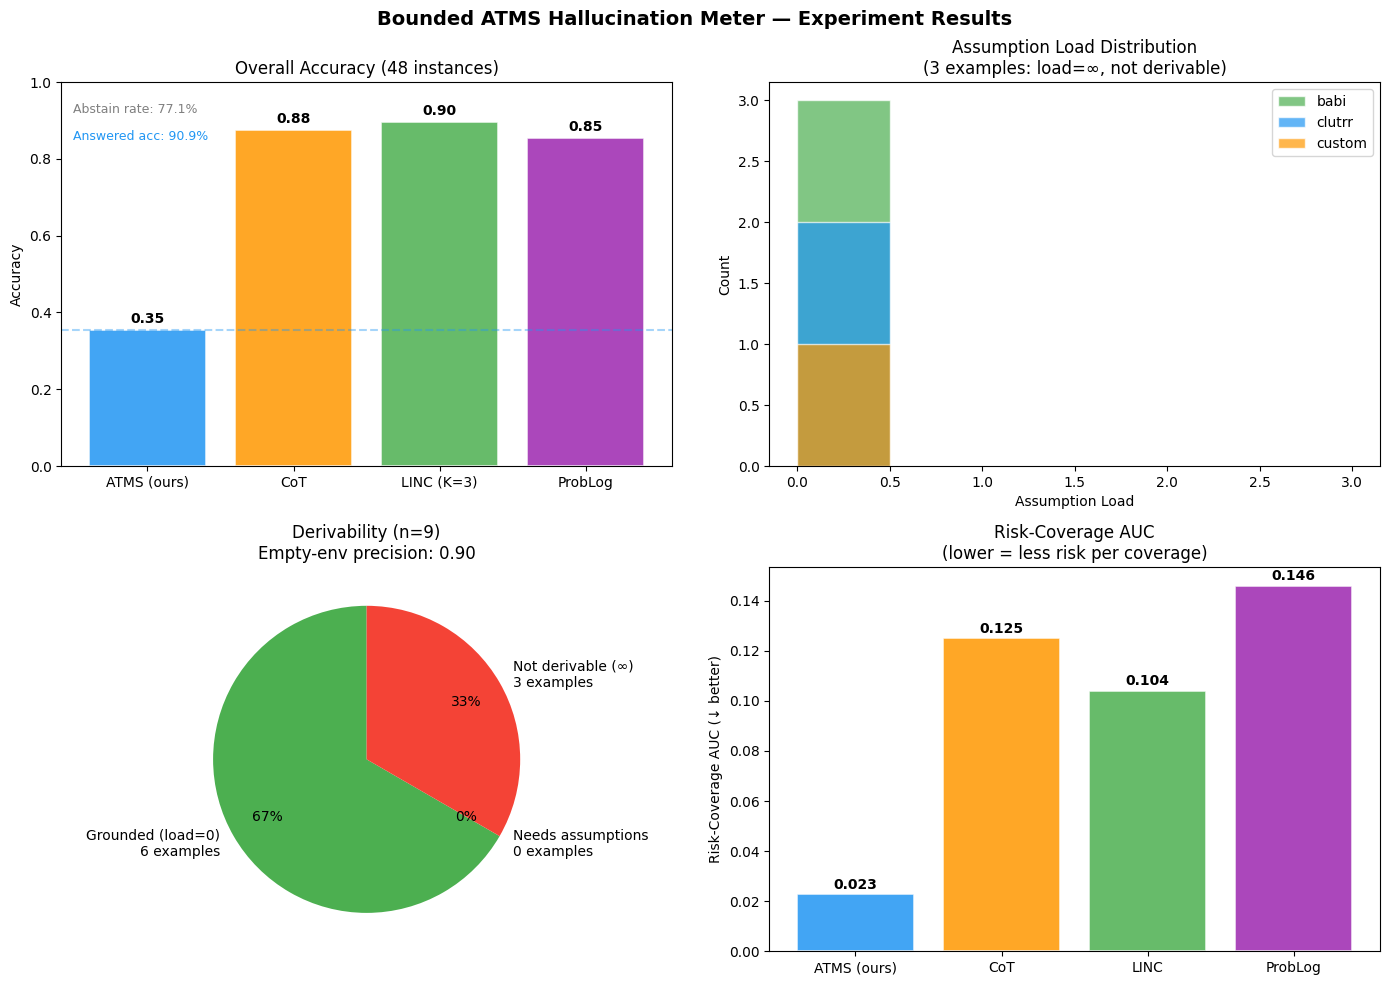

Saved atms_results.png

=== Summary ===
Metric                                   Value               
------------------------------------------------------------
Empty-env precision                      0.900
Spearman rho (load vs error)             -0.100
Abstain rate                             77.1%
Answered accuracy (ATMS)                 90.9%
Overall accuracy — ATMS                  0.354
Overall accuracy — CoT                   0.875
Overall accuracy — LINC                  0.896
Overall accuracy — ProbLog               0.854
Total LLM cost (48 instances)            $0.0072


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bounded ATMS Hallucination Meter — Experiment Results", fontsize=14, fontweight="bold")

eval_meta = data["metadata"]["evaluation"]

# ── Plot 1: Overall Accuracy ──────────────────────────────────────────────────
ax1 = axes[0, 0]
methods = ["our_method", "cot", "linc", "problog"]
labels = ["ATMS (ours)", "CoT", "LINC (K=3)", "ProbLog"]
accs = [eval_meta["overall_accuracy"][m] for m in methods]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
bars = ax1.bar(labels, accs, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
ax1.set_ylabel("Accuracy")
ax1.set_title("Overall Accuracy (48 instances)")
ax1.set_ylim(0, 1.0)
ax1.axhline(eval_meta["overall_accuracy"]["our_method"], color="#2196F3", linestyle="--", alpha=0.4)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f"{acc:.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.text(0.02, 0.92, f"Abstain rate: {eval_meta['abstain_rate']:.1%}", transform=ax1.transAxes,
         fontsize=9, color="gray")
ax1.text(0.02, 0.85, f"Answered acc: {eval_meta['answered_accuracy_our_method']:.1%}", transform=ax1.transAxes,
         fontsize=9, color="#2196F3")

# ── Plot 2: Assumption Load Distribution ─────────────────────────────────────
ax2 = axes[0, 1]
finite_df = df[df["assumption_load"] < float("inf")]
inf_count = (df["assumption_load"] == float("inf")).sum()
dataset_colors = {"clutrr": "#2196F3", "babi": "#4CAF50", "custom": "#FF9800"}
for ds_name, group in finite_df.groupby("dataset"):
    ax2.hist(group["assumption_load"], bins=[0, 0.5, 1, 1.5, 2, 2.5, 3],
             alpha=0.7, label=ds_name, color=dataset_colors.get(ds_name, "gray"), edgecolor="white")
ax2.set_xlabel("Assumption Load")
ax2.set_ylabel("Count")
ax2.set_title(f"Assumption Load Distribution\n({inf_count} examples: load=∞, not derivable)")
ax2.legend()

# ── Plot 3: Empty-Env Derivable vs Requires Assumptions ──────────────────────
ax3 = axes[1, 0]
ee_count = df["empty_env_derivable"].sum()
non_ee_finite = ((~df["empty_env_derivable"]) & (df["assumption_load"] < float("inf"))).sum()
non_derivable = (df["assumption_load"] == float("inf")).sum()
sizes = [ee_count, non_ee_finite, non_derivable]
labels_pie = [
    f"Grounded (load=0)\n{ee_count} examples",
    f"Needs assumptions\n{non_ee_finite} examples",
    f"Not derivable (∞)\n{non_derivable} examples",
]
pie_colors = ["#4CAF50", "#FF9800", "#f44336"]
ax3.pie(sizes, labels=labels_pie, colors=pie_colors, autopct="%1.0f%%",
        startangle=90, pctdistance=0.75)
ax3.set_title(f"Derivability (n={len(df)})\nEmpty-env precision: {eval_meta['empty_env_precision']:.2f}")

# ── Plot 4: Risk-Coverage AUC (lower = better) ────────────────────────────────
ax4 = axes[1, 1]
rc_methods = ["our_method", "cot", "linc_vote", "problog"]
rc_labels = ["ATMS (ours)", "CoT", "LINC", "ProbLog"]
rc_aucs = [eval_meta["risk_coverage_auc"][m] for m in rc_methods]
bars4 = ax4.bar(rc_labels, rc_aucs, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
ax4.set_ylabel("Risk-Coverage AUC (↓ better)")
ax4.set_title("Risk-Coverage AUC\n(lower = less risk per coverage)")
for bar, auc in zip(bars4, rc_aucs):
    ax4.text(bar.get_x() + bar.get_width() / 2, auc + 0.001, f"{auc:.3f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("atms_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved atms_results.png")

# Summary table
print("\n=== Summary ===")
print(f"{'Metric':<40} {'Value':<20}")
print("-" * 60)
print(f"{'Empty-env precision':<40} {eval_meta['empty_env_precision']:.3f}")
print(f"{'Spearman rho (load vs error)':<40} {eval_meta['spearman_rho']:.3f}")
print(f"{'Abstain rate':<40} {eval_meta['abstain_rate']:.1%}")
print(f"{'Answered accuracy (ATMS)':<40} {eval_meta['answered_accuracy_our_method']:.1%}")
print(f"{'Overall accuracy — ATMS':<40} {eval_meta['overall_accuracy']['our_method']:.3f}")
print(f"{'Overall accuracy — CoT':<40} {eval_meta['overall_accuracy']['cot']:.3f}")
print(f"{'Overall accuracy — LINC':<40} {eval_meta['overall_accuracy']['linc']:.3f}")
print(f"{'Overall accuracy — ProbLog':<40} {eval_meta['overall_accuracy']['problog']:.3f}")
print(f"{'Total LLM cost (48 instances)':<40} ${data['metadata']['total_cost_usd']:.4f}")